# CG4002: PyTorch 1D-CNN Trainer & HLS Export
---
**Target:** Xilinx Ultra96-V2 (Vitis HLS)  
**Framework:** PyTorch  
**Architecture:** 1D-CNN (Input: 6 axes x 60 samples)
- PyTorch Conv1d expects input as `(Batch, Channels, Length)` -> `(Batch, 6, 60)`.
- This notebook handles the transposition automatically.

---
**Notebook Structure:**
1. Import dependencies
2. Data processing & augmentation
3. Model definition
4. Training
5. Export weights for HLS

## 1. Import dependencies & configuration

In [28]:
# Install required packages (uncomment if needed)
!pip install pandas numpy scikit-learn

In [29]:
# Install PyTorch (uncomment if needed)
# For CUDA-enabled GPUs:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# For CPU-only:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [30]:
%pip install --upgrade pip setuptools wheel
%pip install --force-reinstall --no-cache-dir scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.4 MB/s  0:00:14m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 1.6 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.8 MB/s  0:00:02 eta 0:00:01
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.00m 0/5 [threadpoolctl]
  Attempting uninstall: numpy━━━━━━━━━━━━━━━ 0/5 [threadpoolctl]
    Found existing installation: numpy 2.4.2 0/5 [threadpoolctl]
    Uninstalling numpy-2.4.2:━━━━━━━━━━━━━━━ 0/5 [threadpoolctl]
      Successfully uninstalled numpy-2.4.2━━ 0/5 [threadpoolctl]
  Attempting uninstall: joblib━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation: joblib 1.5.3━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Uninstalling joblib-1.5.3:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [31]:
%pip install --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cpu

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/nightly/cpu
Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from datetime import datetime
import re

# CONFIGURATION
WINDOW_SIZE = 60
NUM_AXES = 6
NUM_CLASSES = 6
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 0.001
VAL_SIZE = 0.1
EARLY_STOPPING_PATIENCE = 10

# Gesture data root (dated folders: ddmmyyyy)
GESTURE_ROOT = Path("../data/gesture")

def get_latest_gesture_folder(root: Path) -> Path:
    candidates = []
    for d in root.iterdir():
        if not d.is_dir():
            continue
        if re.fullmatch(r"\d{8}", d.name):
            try:
                dt = datetime.strptime(d.name, "%d%m%Y")
                candidates.append((dt, d))
            except ValueError:
                pass
    if not candidates:
        raise RuntimeError(f"No dated gesture folders found under: {root.resolve()}")
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

GESTURE_DIR = get_latest_gesture_folder(GESTURE_ROOT)
print(f"Using latest gesture folder: {GESTURE_DIR}")

# Keep all intermediate files inside this date folder
IMUDATA_CSV = GESTURE_DIR / "imudata.csv"
RESAMPLED_CSV = GESTURE_DIR / "resampled_imudata.csv"
AUGMENTED_CSV = GESTURE_DIR / "augmented_imudata.csv"
TRAIN_CSV_OUT = GESTURE_DIR / "augmented_imudata_train.csv"
VAL_CSV_OUT = GESTURE_DIR / "augmented_imudata_val.csv"
TEST_CSV_OUT = GESTURE_DIR / "augmented_imudata_test.csv"
MEAN_NPY = GESTURE_DIR / "mean.npy"
STD_NPY = GESTURE_DIR / "std.npy"
WEIGHTS_H_PATH = GESTURE_DIR / "gesture_cnn_weights.h"
GESTURE_TEST_X_NPY = GESTURE_DIR / "gesture_X_test.npy"
GESTURE_TEST_Y_NPY = GESTURE_DIR / "gesture_y_test.npy"

# If an augmented CSV already exists in this date folder, reuse it directly.
USE_EXISTING_AUGMENTED_CSV = AUGMENTED_CSV.exists()
if USE_EXISTING_AUGMENTED_CSV:
    print(f"Detected prebuilt dataset CSV: {AUGMENTED_CSV}")


# Explicit class semantics used in this notebook
PROJECT_TARGET_LABELS = ["Raise", "Shake", "Chop", "Stir", "Swing", "Punch"]
PUBLIC_DATASET_LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

if USE_EXISTING_AUGMENTED_CSV:
    ACTIVE_LABELS = PUBLIC_DATASET_LABELS
    print(f"Active gesture labels (public dataset): {ACTIVE_LABELS}")
else:
    ACTIVE_LABELS = PROJECT_TARGET_LABELS
    print(f"Active gesture labels (project target): {ACTIVE_LABELS}")

# canonical gesture labels (filename stems) and class IDs
CLASS_MAP = {
    "raise": 0,
    "shake3": 1,
    "vertical": 2,
    "circular": 3,
    "horizontal": 4,
    "punch": 5,
}

SENSOR_COLUMNS = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']
HEADER_MARKER = "YPR(deg)-X"

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using latest gesture folder: ../data/gesture/27022026
Detected prebuilt dataset CSV: ../data/gesture/27022026/augmented_imudata.csv
Active gesture labels (public dataset): ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Using device: cpu


## 2. Data processing & augmentation

### 2.1 Read and parse raw gesture data from text files

In [33]:
import glob


def get_label_name(file_path: Path) -> str:
    return file_path.stem.strip().lower()


def read_log_lines(file_path: Path):
    """Load txt logs robustly (handles UTF-16 and UTF-8 exports)."""
    raw = file_path.read_bytes()

    text = None
    for enc in ("utf-16", "utf-8-sig", "utf-8"):
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            pass

    if text is None:
        text = raw.decode("utf-8", errors="ignore")

    text = text.replace("\x00", "")
    return text.splitlines()


def parse_sensor_row(line: str):
    """Return a 6-value sensor row as floats, or None for non-data lines."""
    line = line.strip()

    if not line or line.startswith("---"):
        return None

    parts = [p.strip() for p in line.split(",")]
    if len(parts) != 6:
        return None

    try:
        return [float(p) for p in parts]
    except ValueError:
        return None


def extract_recordings(file_path: Path):
    """Parse serial txt into recording blocks split by repeated CSV headers."""
    lines = read_log_lines(file_path)

    recordings = []
    current_block = []
    in_data_section = False

    for raw_line in lines:
        line = raw_line.strip()

        if HEADER_MARKER in line:
            if current_block:
                recordings.append(np.array(current_block, dtype=np.float32))
                current_block = []
            in_data_section = True
            continue

        if not in_data_section:
            continue

        parsed = parse_sensor_row(line)
        if parsed is not None:
            current_block.append(parsed)

    if current_block:
        recordings.append(np.array(current_block, dtype=np.float32))

    return recordings


def load_all_recordings(txt_dir: Path, min_len: int = 10):
    files = sorted(txt_dir.glob("*.txt"))
    print(f"Found {len(files)} files in {txt_dir}")

    recordings = []
    for file_path in files:
        label_name = get_label_name(file_path)
        if label_name not in CLASS_MAP:
            print(f"Skipping {file_path.name} (unknown label: {label_name})")
            continue

        label_id = CLASS_MAP[label_name]
        blocks = extract_recordings(file_path)
        valid_blocks = [b for b in blocks if len(b) >= min_len]

        print(
            f"Processing '{file_path.name}' -> Class {label_id} "
            f"({len(valid_blocks)}/{len(blocks)} valid blocks)"
        )

        for block in valid_blocks:
            recordings.append((block, label_id, label_name))

    if not recordings:
        raise RuntimeError("No valid recordings parsed from txt files.")

    return recordings


def parse_and_convert(txt_dir: Path):
    recordings = load_all_recordings(txt_dir)

    all_data_rows = []
    for measurement_id, (block, label_id, label_name) in enumerate(recordings):
        for sequence_id, sample in enumerate(block):
            all_data_rows.append({
                "measurement_id": measurement_id,
                "sequence_id": sequence_id,
                "label_id": label_id,
                "label": label_name,
                "gyro_x": sample[0],
                "gyro_y": sample[1],
                "gyro_z": sample[2],
                "acc_x": sample[3],
                "acc_y": sample[4],
                "acc_z": sample[5],
            })

    df = pd.DataFrame(all_data_rows)
    df.to_csv(IMUDATA_CSV, index=False)
    print(f"SUCCESS! Processed {df['measurement_id'].nunique()} distinct recordings.")
    print(f"Total rows: {len(df)}")
    print(f"Saved to: {IMUDATA_CSV}")
    print("Sample Data:")
    print(df.head())


# Run parser only when no prebuilt augmented CSV is available
if USE_EXISTING_AUGMENTED_CSV:
    print("Skipping TXT parsing: using prebuilt augmented CSV.")
else:
    parse_and_convert(GESTURE_DIR)


Skipping TXT parsing: using prebuilt augmented CSV.


### 2.2 Resample gesture data to fixed window size

In [34]:
if USE_EXISTING_AUGMENTED_CSV:
    print("Skipping resample step: using prebuilt augmented CSV.")
else:
    from scipy import signal

    TARGET_LEN = WINDOW_SIZE
    OUTPUT_CSV = RESAMPLED_CSV

    all_recordings = [
        (block, label_id, label_name, measurement_id)
        for measurement_id, (block, label_id, label_name) in enumerate(load_all_recordings(GESTURE_DIR))
    ]

    resampled_rows = []
    for raw_data, label_id, label_name, m_id in all_recordings:
        resampled_data = signal.resample(raw_data, TARGET_LEN)
        for i in range(TARGET_LEN):
            resampled_rows.append({
                "measurement_id": m_id,
                "sequence_id": i,
                "label_id": label_id,
                "label": label_name,
                "gyro_x": resampled_data[i, 0],
                "gyro_y": resampled_data[i, 1],
                "gyro_z": resampled_data[i, 2],
                "acc_x": resampled_data[i, 3],
                "acc_y": resampled_data[i, 4],
                "acc_z": resampled_data[i, 5],
            })

    if resampled_rows:
        final_df = pd.DataFrame(resampled_rows)
        final_df.to_csv(OUTPUT_CSV, index=False)
        print(f"SUCCESS! Saved to {OUTPUT_CSV}")
        print(f"Total Rows: {len(final_df)}")
        print(f"Unique Gestures: {final_df['measurement_id'].nunique()}")
    else:
        print("Error: No data found.")


Skipping resample step: using prebuilt augmented CSV.


### 2.3 Data augmentation (jitter, scaling, shift, time warping)

In [35]:
if USE_EXISTING_AUGMENTED_CSV:
    print("Skipping augmentation step: using prebuilt augmented CSV.")
else:
    AUGMENT_FACTOR = 10
    OUTPUT_CSV = AUGMENTED_CSV

    raw_recordings = load_all_recordings(GESTURE_DIR)

    final_rows = []
    global_id = 0

    for raw_data, label_id, label_name in raw_recordings:
        seq_len = len(raw_data)

        for i in range(AUGMENT_FACTOR):
            aug_data = raw_data.copy()
            if i > 0:
                noise = np.random.normal(0, 0.05, aug_data.shape)
                aug_data += noise
                scale = np.random.uniform(0.8, 1.2)
                aug_data *= scale
                shift = np.random.uniform(-0.1, 0.1, size=(1, 6))
                aug_data += shift

            if i > 5 and seq_len > 20:
                crop_start = np.random.randint(0, int(seq_len * 0.1))
                crop_end = seq_len - np.random.randint(0, int(seq_len * 0.1))
                aug_data = aug_data[crop_start:crop_end]

            resampled_data = signal.resample(aug_data, WINDOW_SIZE)

            for t in range(WINDOW_SIZE):
                final_rows.append({
                    "measurement_id": global_id,
                    "sequence_id": t,
                    "label_id": label_id,
                    "label": label_name,
                    "gyro_x": resampled_data[t, 0],
                    "gyro_y": resampled_data[t, 1],
                    "gyro_z": resampled_data[t, 2],
                    "acc_x": resampled_data[t, 3],
                    "acc_y": resampled_data[t, 4],
                    "acc_z": resampled_data[t, 5],
                })
            global_id += 1


    df_final = pd.DataFrame(final_rows)
    df_final.to_csv(OUTPUT_CSV, index=False)
    print("SUCCESS!")
    print(f"Original Gestures: {len(raw_recordings)}")
    print(f"Augmented Gestures: {global_id} (Target: ~{len(raw_recordings) * AUGMENT_FACTOR})")
    print(f"Total Rows: {len(df_final)}")
    print(f"Saved to: {OUTPUT_CSV}")


Skipping augmentation step: using prebuilt augmented CSV.


## 3. Model definition & training

## 3.1 Load Data

In [36]:
# Load and preprocess augmented data for training (NO leakage)
CSV_PATH = AUGMENTED_CSV

print(f"Loading {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

feature_cols = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']
id_col = "measurement_id"
time_col = "sequence_id"
label_col = "label_id"

# Derive active label names from loaded dataset when available.
if 'label' in df.columns:
    label_rows = df[[label_col, 'label']].dropna().drop_duplicates().copy()
    label_rows[label_col] = pd.to_numeric(label_rows[label_col], errors='coerce')
    label_rows = label_rows.dropna().sort_values(label_col)
    ACTIVE_LABELS = [str(x) for x in label_rows['label'].tolist()]
else:
    ACTIVE_LABELS = ACTIVE_LABELS if 'ACTIVE_LABELS' in globals() else [str(i) for i in range(NUM_CLASSES)]
print(f"Active gesture labels: {ACTIVE_LABELS}")

# -----------------------------
# 1) Keep only valid windows
# -----------------------------
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

valid_ids = []
labels_per_id = []

grouped = df.groupby(id_col, sort=False)
for mid, g in grouped:
    if len(g) != WINDOW_SIZE:
        continue
    if g[time_col].isna().any():
        continue
    if g[time_col].nunique() != WINDOW_SIZE:
        continue
    lid0 = int(g.iloc[0][label_col])
    if not (g[label_col] == lid0).all():
        continue

    valid_ids.append(mid)
    labels_per_id.append(lid0)

valid_ids = np.array(valid_ids)
labels_per_id = np.array(labels_per_id)

print(f"Detected {len(valid_ids)} valid gesture samples (windows).")
if len(valid_ids) == 0:
    raise RuntimeError("No valid windows found. Check WINDOW_SIZE / CSV integrity.")

# -----------------------------
# 2) Split by measurement_id: train/test, then train/val
# -----------------------------
train_ids, test_ids, y_train_ids, y_test_ids = train_test_split(
    valid_ids,
    labels_per_id,
    test_size=0.2,
    random_state=42,
    stratify=labels_per_id,
)

train_ids_inner, val_ids, y_train_inner, y_val = train_test_split(
    train_ids,
    y_train_ids,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_train_ids,
)

df_train = df[df[id_col].isin(train_ids_inner)].copy()
df_val = df[df[id_col].isin(val_ids)].copy()
df_test = df[df[id_col].isin(test_ids)].copy()

df_train.sort_values([id_col, time_col], ascending=True, kind="mergesort", inplace=True)
df_val.sort_values([id_col, time_col], ascending=True, kind="mergesort", inplace=True)
df_test.sort_values([id_col, time_col], ascending=True, kind="mergesort", inplace=True)

# Save split CSVs in the same latest date folder
df_train.to_csv(TRAIN_CSV_OUT, index=False)
df_val.to_csv(VAL_CSV_OUT, index=False)
df_test.to_csv(TEST_CSV_OUT, index=False)
print(
    f"Saved: {TRAIN_CSV_OUT} ({len(df_train)} rows), "
    f"{VAL_CSV_OUT} ({len(df_val)} rows), "
    f"{TEST_CSV_OUT} ({len(df_test)} rows)"
)

# -----------------------------
# 3) Build numpy windows (TRAIN/VAL/TEST)
# -----------------------------
def df_to_windows(df_part, ids, window_size, feature_cols, label_col):
    X_list = []
    y_list = []
    for mid in ids:
        g = df_part[df_part[id_col] == mid]
        if len(g) != window_size:
            continue
        x = g[feature_cols].to_numpy(dtype=np.float32)  # (60,6)
        y = int(g.iloc[0][label_col])
        X_list.append(x)
        y_list.append(y)
    X = np.stack(X_list, axis=0)  # (N,60,6)
    y = np.array(y_list, dtype=np.int64)
    return X, y

X_train_raw, y_train = df_to_windows(df_train, train_ids_inner, WINDOW_SIZE, feature_cols, label_col)
X_val_raw, y_val = df_to_windows(df_val, val_ids, WINDOW_SIZE, feature_cols, label_col)
X_test_raw, y_test = df_to_windows(df_test, test_ids, WINDOW_SIZE, feature_cols, label_col)

print(f"Raw shapes: X_train={X_train_raw.shape}, X_val={X_val_raw.shape}, X_test={X_test_raw.shape}")

# Save board-input test tensors (raw, unnormalized) for dual_cnn_test.py
np.save(GESTURE_TEST_X_NPY, X_test_raw.astype(np.float32))
np.save(GESTURE_TEST_Y_NPY, y_test.astype(np.int64))
print(f"Saved gesture board test npy: {GESTURE_TEST_X_NPY}, {GESTURE_TEST_Y_NPY}")

# -----------------------------
# 4) Fit scaler on TRAIN only
# -----------------------------
scaler = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, NUM_AXES)
X_val_flat = X_val_raw.reshape(-1, NUM_AXES)
X_test_flat = X_test_raw.reshape(-1, NUM_AXES)

scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)
X_val_scaled = scaler.transform(X_val_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)

# Save mean/std to canonical deployment paths
np.save(MEAN_NPY, scaler.mean_)
np.save(STD_NPY, scaler.scale_)
print(f"Saved mean/std to: {MEAN_NPY}, {STD_NPY} (TRAIN-fitted)")
print(f"Scaler mean: {scaler.mean_}, std: {scaler.scale_}")

# -----------------------------
# 5) Convert to [Batch, Channels, Time]
# -----------------------------
X_train = np.transpose(X_train_scaled, (0, 2, 1)).astype(np.float32)  # (N,6,60)
X_val = np.transpose(X_val_scaled, (0, 2, 1)).astype(np.float32)      # (N,6,60)
X_test = np.transpose(X_test_scaled, (0, 2, 1)).astype(np.float32)    # (N,6,60)

# To torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Ready! Train shape: {X_train.shape} | Val shape: {X_val.shape} | Test shape: {X_test.shape}")



Loading ../data/gesture/27022026/augmented_imudata.csv...
Active gesture labels: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Detected 7352 valid gesture samples (windows).
Saved: ../data/gesture/27022026/augmented_imudata_train.csv (317520 rows), ../data/gesture/27022026/augmented_imudata_val.csv (35340 rows), ../data/gesture/27022026/augmented_imudata_test.csv (88260 rows)
Raw shapes: X_train=(5292, 60, 6), X_val=(589, 60, 6), X_test=(1471, 60, 6)
Saved gesture board test npy: ../data/gesture/27022026/gesture_X_test.npy, ../data/gesture/27022026/gesture_y_test.npy
Saved mean/std to: ../data/gesture/27022026/mean.npy, ../data/gesture/27022026/std.npy (TRAIN-fitted)
Scaler mean: [ 2.31284325e-03 -8.78569129e-04 -9.18387133e-04 -7.16640085e-04
 -1.48521774e-05 -1.16569765e-04], std: [0.40777881 0.38327034 0.25755577 0.19436369 0.12311977 0.10720748]
✅ Data Ready! Train shape: (5292, 6, 60) | Val shape: (589, 6, 60) | Test shape: (1471, 6, 60)


## 3.2 Model Architecture

In [37]:
import torch.nn as nn

class GestureCNN(nn.Module):
    def __init__(self):
        super(GestureCNN, self).__init__()
        
        # Layer 1: Input 6 -> Output 16
        self.conv1 = nn.Conv1d(in_channels=6, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # 60 -> 30
        
        # Layer 2: Input 16 -> Output 32
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # 30 -> 15
        
        # Flatten Calculation:
        # Final Length = 15
        # Final Channels = 32
        # Flatten Size = 15 * 32 = 480
        self.flatten_size = 15 * 32
        
        # Dense Layers
        self.fc1 = nn.Linear(self.flatten_size, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, NUM_CLASSES) # Output 6 classes
        
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Classifier
        x = x.view(-1, self.flatten_size) # Flatten
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

# Instantiate and move to GPU
model = GestureCNN().to(device)
print(f"✅ Model Initialized on {device}")
print(model)

✅ Model Initialized on cpu
GestureCNN(
  (conv1): Conv1d(6, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=480, out_features=32, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=32, out_features=6, bias=True)
)


## 3.3 Training  Loop

In [38]:
import copy
import torch.optim as optim

# Hyperparameters
EPOCHS = 40
LEARNING_RATE = 0.001

# Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
)

def evaluate_loader(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100.0 * correct / max(total, 1)

print(f"🚀 Starting training for {EPOCHS} epochs...")

best_val_acc = -1.0
best_state = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100.0 * correct / max(total, 1)
    avg_loss = running_loss / max(len(train_loader), 1)

    # --- VALIDATE ---
    val_acc = evaluate_loader(model, val_loader)
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | "
            f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.6f}"
        )

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:
        print(f"⏹️ Early stopping at epoch {epoch+1} (best val acc: {best_val_acc:.2f}%)")
        break

# Restore best validated checkpoint before final test evaluation
model.load_state_dict(best_state)
print(f"✅ Training Complete. Best Val Acc: {best_val_acc:.2f}%")



🚀 Starting training for 40 epochs...
Epoch 1/40 | Loss: 0.9796 | Train Acc: 51.6% | Val Acc: 63.7% | LR: 0.001000
Epoch 5/40 | Loss: 0.4963 | Train Acc: 77.4% | Val Acc: 77.2% | LR: 0.001000
Epoch 10/40 | Loss: 0.3137 | Train Acc: 86.1% | Val Acc: 83.4% | LR: 0.001000
Epoch 15/40 | Loss: 0.2512 | Train Acc: 90.0% | Val Acc: 86.9% | LR: 0.001000
Epoch 20/40 | Loss: 0.1782 | Train Acc: 92.6% | Val Acc: 89.3% | LR: 0.001000
Epoch 25/40 | Loss: 0.1451 | Train Acc: 94.3% | Val Acc: 89.8% | LR: 0.001000
Epoch 30/40 | Loss: 0.1118 | Train Acc: 96.0% | Val Acc: 90.7% | LR: 0.001000
Epoch 35/40 | Loss: 0.0813 | Train Acc: 97.1% | Val Acc: 90.5% | LR: 0.000500
Epoch 40/40 | Loss: 0.0709 | Train Acc: 97.3% | Val Acc: 90.8% | LR: 0.000500
✅ Training Complete. Best Val Acc: 91.17%


### Float vs Q8.8-Sim Gesture Check
Evaluate the trained gesture model using normal float inputs and simulated Q8.8 quantized inputs before hardware export.

Final Test Accuracy (float): 93.27%
Final Test Accuracy (Q8.8-sim): 93.41%


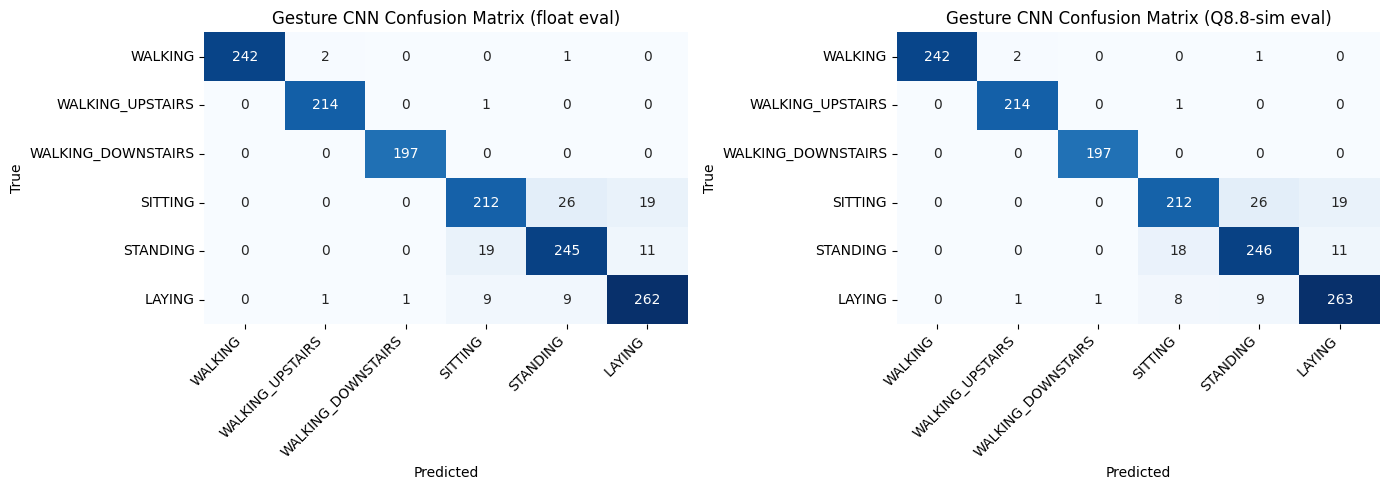

In [39]:
import seaborn as sns


def quantize_q88_dequant(x_t: torch.Tensor) -> torch.Tensor:
    """Simulate Q8.8 by quantizing to int16 range then dequantizing back to float."""
    q = torch.round(torch.clamp(x_t, -128.0, 127.99609375) * 256.0)
    return q / 256.0


def eval_loader(model, loader, q88_sim: bool = False):
    model.eval()
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            x = quantize_q88_dequant(inputs) if q88_sim else inputs
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            yt = labels.detach().cpu().numpy()
            yp = preds.detach().cpu().numpy()
            for t, p in zip(yt, yp):
                cm[int(t), int(p)] += 1

    acc = 100.0 * correct / max(total, 1)
    return acc, cm


acc_float, cm_float = eval_loader(model, test_loader, q88_sim=False)
acc_q88, cm_q88 = eval_loader(model, test_loader, q88_sim=True)

print(f"Final Test Accuracy (float): {acc_float:.2f}%")
print(f"Final Test Accuracy (Q8.8-sim): {acc_q88:.2f}%")

labels = ACTIVE_LABELS if ('ACTIVE_LABELS' in globals() and len(ACTIVE_LABELS) == NUM_CLASSES) else [str(i) for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_float, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Gesture CNN Confusion Matrix (float eval)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_yticklabels(labels, rotation=0)

sns.heatmap(cm_q88, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Gesture CNN Confusion Matrix (Q8.8-sim eval)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


## 4. Export to C++ Header (`weights.h`)
This extracts the trained parameters from `model.state_dict()` and formats them for your HLS code.

In [ ]:
def export_pytorch_weights(model, filename=WEIGHTS_H_PATH, fuse_input_norm=False, norm_mean=None, norm_std=None):
    print(f"Exporting weights to {filename}...")

    params = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if fuse_input_norm:
        if norm_mean is None or norm_std is None:
            raise ValueError("norm_mean and norm_std are required when fuse_input_norm=True")

        conv_w_key = "conv1.weight"
        conv_b_key = "conv1.bias"
        if conv_w_key not in params or conv_b_key not in params:
            raise KeyError("conv1 weights/bias not found in model state_dict")

        mean_t = torch.as_tensor(norm_mean, dtype=params[conv_w_key].dtype)
        std_t = torch.as_tensor(norm_std, dtype=params[conv_w_key].dtype)

        in_ch = params[conv_w_key].shape[1]
        if mean_t.numel() != in_ch or std_t.numel() != in_ch:
            raise ValueError(f"Expected mean/std with {in_ch} values, got {mean_t.numel()} and {std_t.numel()}")
        if torch.any(std_t == 0):
            raise ValueError("std contains zero; cannot fuse normalization")

        inv_std = (1.0 / std_t).view(1, -1, 1)
        params[conv_w_key] = params[conv_w_key] * inv_std

        # bias' = bias - sum_{c,k}(W/std * mean)
        bias_shift = (params[conv_w_key] * mean_t.view(1, -1, 1)).sum(dim=(1, 2))
        params[conv_b_key] = params[conv_b_key] - bias_shift

        print("Fused z-score normalization into conv1 for raw-input inference.")

    filename = Path(filename)
    with open(filename, 'w') as f:
        f.write("#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n")
        f.write("#include \"gesture_typedefs.h\"\n\n")

        total_params = 0

        for name, tensor in params.items():
            clean_name = name.replace(".", "_").replace("weight", "w").replace("bias", "b")
            data = tensor.numpy().flatten()
            size = len(data)
            total_params += size

            print(f"Processing {name} -> {clean_name} ({size} elements)")

            f.write(f"// PyTorch Layer: {name} (Shape: {tuple(tensor.shape)})\n")
            f.write(f"static const data_t {clean_name}[{size}] = {{\n")

            for i, val in enumerate(data):
                f.write(f"{val:.6f}")
                if i < size - 1:
                    f.write(", ")
                if (i + 1) % 10 == 0:
                    f.write("\n    ")
            f.write("\n};\n\n")

        f.write("#endif // WEIGHTS_H\n")

    print(f"\nDone! Total parameters: {total_params}")
    print(f"File saved as '{filename}'. Upload this to Vitis HLS.")

# Run Export
export_pytorch_weights(
    model,
    WEIGHTS_H_PATH,
    fuse_input_norm=True,
    norm_mean=scaler.mean_,
    norm_std=scaler.scale_,
)


Exporting weights to ../data/gesture/27022026/gesture_cnn_weights.h...
Fused z-score normalization into conv1 for raw-input inference.
Processing conv1.weight -> conv1_w (288 elements)
Processing conv1.bias -> conv1_b (16 elements)
Processing conv2.weight -> conv2_w (1536 elements)
Processing conv2.bias -> conv2_b (32 elements)
Processing fc1.weight -> fc1_w (15360 elements)
Processing fc1.bias -> fc1_b (32 elements)
Processing fc2.weight -> fc2_w (192 elements)
Processing fc2.bias -> fc2_b (6 elements)

Done! Total parameters: 17462
File saved as '../data/gesture/27022026/gesture_cnn_weights.h'. Upload this to Vitis HLS.
